In [54]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

from geosynthbench.gen.config import WorldGenConfig
from geosynthbench.gen.pipeline import generate_world
from geosynthbench.paths import DATA_DIR
from geosynthbench.render.renderer import (
    render_world_textured,
)
from geosynthbench.world.raster import RasterTransform

cfg = WorldGenConfig(
    seed=0,
    # terrain
    terrain_amplitude_m=30.0,
    terrain_n_hills=(1, 5),
    terrain_hill_sigma_m=(250.0, 900.0),
    terrain_noise_scale_m=300.0,
    terrain_noise_strength_m=6.0,
    # water / vegetation counts
    n_water=(1, 3),
    n_veg=(3, 6),
    # settlements
    n_settlements=(2, 5),
    settlement_radius_m=(180.0, 400.0),
    min_dist_settlements_m=500.0,
    max_slope_settlement=0.25,  # ~ 25%
    # roads
    roads_mode="mst+extras",  # "mst", "mst+extras", "ring", "dense"
    extra_edges=1,
    road_width_m=8.0,
    max_slope_road=0.1,
    # buildings
    buildings_per_settlement=(10, 30),
    building_size_m=(12.0, 30.0),  # square-ish side
    min_dist_buildings_m=6.0,
    max_slope_building=0.20,
    max_building_attempts=2000,
    # hard rule toggles
    require_connected_roads=True,
    forbid_roads_in_water=True,
    # soft preferences
    prefer_settlement_near_water=True,
    prefer_water_distance_m=(60.0, 350.0),  # target band
)
tr = RasterTransform(extent=(0, 0, 512 * 5, 512 * 5), width_px=512, height_px=512)

# world = generate_world(tr=tr, cfg=cfg)
# img, mask_res = render_world_textured(world, rng=np.random.default_rng(42))
# plt.imshow(img)

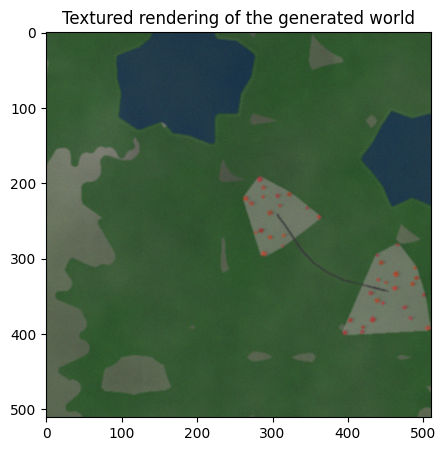

In [58]:
t0_cfg = WorldGenConfig(
    seed=0,
    # terrain
    terrain_amplitude_m=300.0,
    terrain_n_hills=(3, 5),
    terrain_hill_sigma_m=(250.0, 500.0),
    terrain_noise_scale_m=300.0,
    terrain_noise_strength_m=6.0,
    # water / vegetation counts
    n_water=(1, 3),
    n_veg=(3, 6),
    # settlements
    n_settlements=2,  # not too many settlement
    # roads
)
world = generate_world(tr=tr, cfg=t0_cfg)
assert world.settlements is not None
img = render_world_textured(world, rng=np.random.default_rng(42))
plt.figure(figsize=(5, 5))
plt.title("Textured rendering of the generated world")
plt.imshow(img);

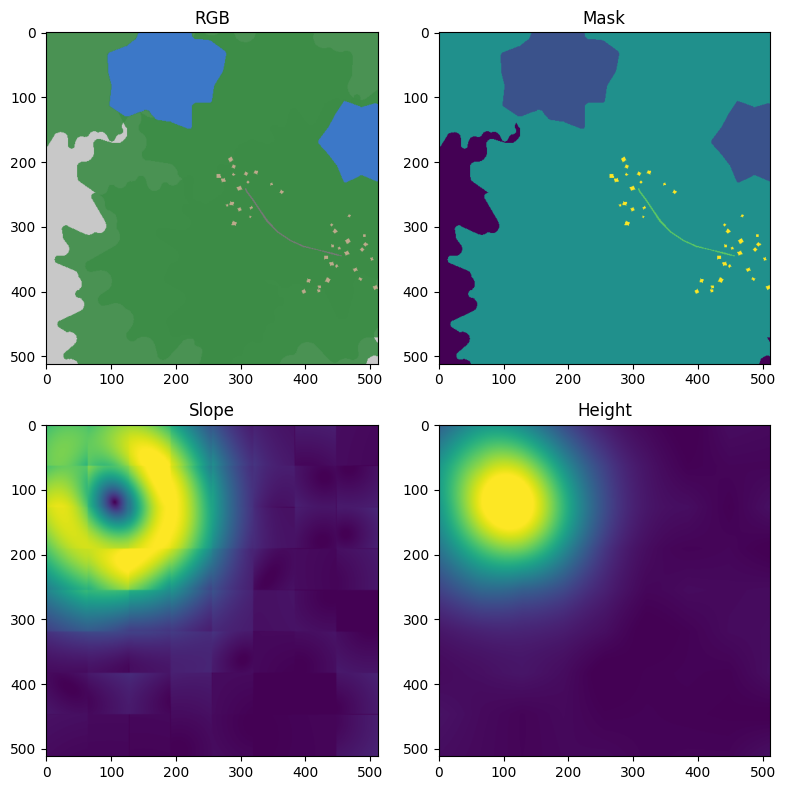

In [59]:
import matplotlib.pyplot as plt

from geosynthbench.render.raster_renderer import render_world_debug

res = render_world_debug(world)

# plot the 4 images in a 2x2 grid
fig, axs = plt.subplots(2, 2, figsize=(8, 8))
axs[0, 0].imshow(res.rgb)
axs[0, 1].imshow(res.mask)
axs[1, 0].imshow(res.slope)
axs[1, 1].imshow(res.height)
# add titles
axs[0, 0].set_title("RGB")
axs[0, 1].set_title("Mask")
axs[1, 0].set_title("Slope")
axs[1, 1].set_title("Height")
plt.tight_layout()
plt.show();

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

from geosynthbench.dataset import WorldsDataset
from geosynthbench.render.renderer import render_world_textured

world_dataset = WorldsDataset(DATA_DIR / "dataset_0")

idx = 2
world_state = world_dataset.load_world_state(idx)
img = render_world_textured(world_state, rng=np.random.default_rng(42))

plt.imshow(img)

In [ ]:
# draw a connection graph of settlements and roads for the first world in the dataset

idx = 8
world = world_dataset.load_world_state(idx)
road_network = world.roads
nx.draw(road_network.graph, with_labels=True)